In [1]:
import pandas as pd

path = "../data/raw/Mobile_Parts_Wholesale_Dataset.xlsx"

customers = pd.read_excel(path, sheet_name="Customers")
suppliers = pd.read_excel(path, sheet_name="Suppliers")
products = pd.read_excel(path, sheet_name="Products")
sales = pd.read_excel(path, sheet_name="Sales_Transactions")
inventory = pd.read_excel(path, sheet_name="Inventory")
purchase_orders = pd.read_excel(path, sheet_name="Purchase_Orders")
returns = pd.read_excel(path, sheet_name="Returns_Complaints")

print("Loaded all sheets successfully")
for name, df in [("customers", customers), ("suppliers", suppliers), ("products", products),
                  ("sales", sales), ("inventory", inventory), ("purchase_orders", purchase_orders),
                  ("returns", returns)]:
    print(f"{name}: {df.shape}")

Loaded all sheets successfully
customers: (180, 6)
suppliers: (14, 6)
products: (179, 7)
sales: (7928, 9)
inventory: (179, 5)
purchase_orders: (298, 9)
returns: (180, 6)


In [2]:
for name, df in [("customers", customers), ("suppliers", suppliers), ("products", products),
                  ("sales", sales), ("inventory", inventory), ("purchase_orders", purchase_orders),
                  ("returns", returns)]:
    print(f"--- {name} ---")
    print(df.dtypes)
    print("Nulls:\n", df.isnull().sum()[df.isnull().sum() > 0])
    print()

--- customers ---
customer_id                 object
customer_name               object
shop_type                   object
city                        object
state                       object
first_order_date    datetime64[ns]
dtype: object
Nulls:
 Series([], dtype: int64)

--- suppliers ---
supplier_id       object
supplier_name     object
city              object
country           object
lead_time_days     int64
payment_terms     object
dtype: object
Nulls:
 Series([], dtype: int64)

--- products ---
product_id          object
product_name        object
brand               object
compatible_model    object
part_type           object
unit_price_inr       int64
cost_price_inr       int64
dtype: object
Nulls:
 Series([], dtype: int64)

--- sales ---
order_id                    object
customer_id                 object
product_id                  object
order_date          datetime64[ns]
quantity                     int64
unit_price_inr               int64
discount_pct                 i

Date range: 2025-01-22 00:00:00 to 2026-09-29 00:00:00


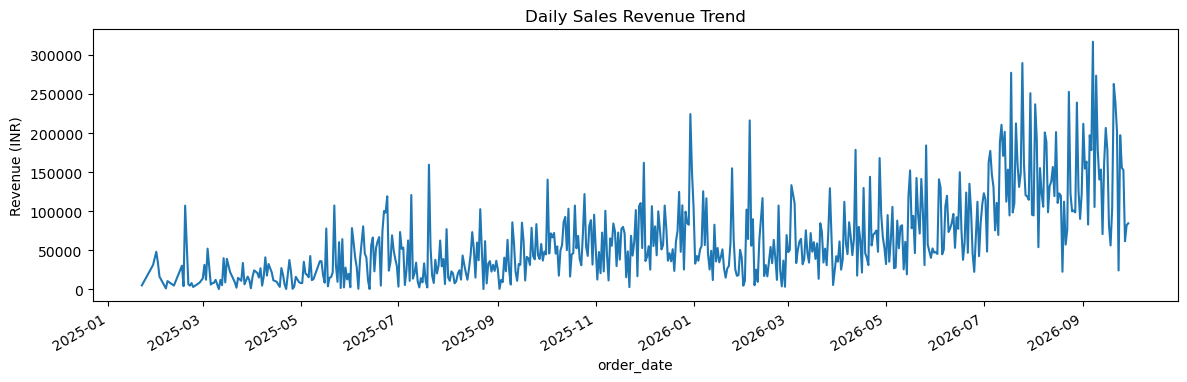

In [3]:
import matplotlib.pyplot as plt

sales['order_date'] = pd.to_datetime(sales['order_date'])
print("Date range:", sales['order_date'].min(), "to", sales['order_date'].max())

daily_sales = sales.groupby('order_date')['total_amount_inr'].sum()

plt.figure(figsize=(14,4))
daily_sales.plot(title="Daily Sales Revenue Trend")
plt.ylabel("Revenue (INR)")
plt.show()